In [31]:
import numpy as np

In [32]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
z = np.array([[0], [1], [1], [1]])

print(X.shape)

(4, 2)


In [33]:
def sigmoid(y):
    return 1/(1+np.exp(-y))

In [34]:
sigmoid(np.array([0, 1, 2]))

array([0.5       , 0.73105858, 0.88079708])

In [35]:
def sigmoid_derivative(z_hat):
    return z_hat * (1-z_hat)

In [36]:
np.random.seed(1000)
w = np.random.randn(2, 1)
b = np.zeros((1, 1))

print(w, w.shape)
print(b, b.shape)

[[-0.8044583 ]
 [ 0.32093155]] (2, 1)
[[0.]] (1, 1)


In [37]:
layer0 = X
y = np.dot(X, w) + b
layer1 = sigmoid(y)
print(y, y.shape)
print(np.dot(X, w))
print(layer1)

[[ 0.        ]
 [ 0.32093155]
 [-0.8044583 ]
 [-0.48352676]] (4, 1)
[[ 0.        ]
 [ 0.32093155]
 [-0.8044583 ]
 [-0.48352676]]
[[0.5       ]
 [0.57955126]
 [0.30907265]
 [0.38141968]]


In [38]:
def forward_compute(X, w, b):
    layer0 = X
    y = np.dot(X, w) + b
    layer1 = sigmoid(y)
    return layer0, layer1

In [39]:
np.dot(X, w), X.shape, w.shape

(array([[ 0.        ],
        [ 0.32093155],
        [-0.8044583 ],
        [-0.48352676]]),
 (4, 2),
 (2, 1))

In [40]:
learning_rate = 0.1
layer0, layer1 = forward_compute(X, w, b)

decision = (layer1 >= 0.5)
error = np.sum(np.abs(decision-z))
loss = np.sum(np.abs(layer1 - z))
print(epoch, error, loss, layer1.T)
# if error == 0: break

layer1_error = layer1 - z
layer1_delta = layer1_error * sigmoid_derivative(layer1)

print(layer1_error)
print(layer1_delta)

0 3 2.2299564067322133 [[0.5        0.57955126 0.30907265 0.38141968]]
[[ 0.5       ]
 [-0.42044874]
 [-0.69092735]
 [-0.61858032]]
[[ 0.125     ]
 [-0.10245142]
 [-0.14754529]
 [-0.14594704]]


In [41]:
print(X.T)
print(X.T.shape, layer1_delta.shape)
print(len(X))

[[0 0 1 1]
 [0 1 0 1]]
(2, 4) (4, 1)
4


In [73]:
learning_rate = 0.1
for epoch in range(1000):
    layer0, layer1 = forward_compute(X, w, b)

    decision = (layer1 >= 0.5)
    error = np.sum(np.abs(decision-z))
    loss = np.sum(np.abs(layer1 - z))
    print(epoch, error, loss, layer1.T)
    if error == 0: break

    layer1_error = layer1 - z
    layer1_delta = layer1_error * sigmoid_derivative(layer1)

    dw = np.dot(X.T, layer1_delta) / len(X)
    db = np.sum(layer1_delta) / len(X)

    w -= learning_rate * dw
    b -= learning_rate * db

0 0 1.029194588305737 [[0.49992978 0.80886475 0.73891131 0.92295914]]


In [74]:
w, b

(array([[1.04059861],
        [1.44293128]]),
 array([[-0.00028088]]))

In [115]:
inputs, hiddens, outputs = 2, 4, 1
W1 = np.random.randn(inputs, hiddens) + 0.5
W2 = np.random.randn(hiddens, outputs) + 0.5
b1 = np.zeros(hiddens)
b2 = np.zeros(outputs)

In [116]:
# W1 = np.array([[1, 1], [-1, -1]], dtype=np.float32)
# W2 = np.array([[1], [1]], dtype=np.float32)
# b1 = np.array([0, 2], dtype=np.float32)
# b2 = np.array([-0.5], dtype=np.float32)
print(W1, W2, b1, b2)

[[ 0.26373755  0.94109793 -0.49241399  0.79550499]
 [ 0.54215969  1.26213902  1.12795647  0.60712324]] [[-1.05526284]
 [-2.40585418]
 [ 1.25576283]
 [-0.79956225]] [0. 0. 0. 0.] [0.]


In [117]:
def prediction(X, W1, W2, b1, b2):
    layer0 = X
    y1 = np.dot(X, W1) + b1
    layer1 = sigmoid(y1)
    y2 = np.dot(layer1, W2) + b2
    layer2 = sigmoid(y2)
    return layer0, layer1, layer2

## Loss = MSE

In [106]:
lossArray = []
learning_rate = 5
for epoch in range(10000):
    # prediction
    layer0, layer1, layer2 = prediction(X, W1, W2, b1, b2)
    z_2_hat = layer2

    # check break condition
    decision = z_2_hat >= 0.5
    error = np.sum(np.abs(decision-z))
    loss = np.sum(np.abs(z_2_hat-z))
    lossArray.append(loss)
    print(epoch, error, loss, z_2_hat.T)
    # if error == 0: break 
    # 요거 break넣어주고 안넣어주고 따라 그래프 형태가 좀 바뀜

    # Backpropagation
    layer2_error = layer2 - z
    layer2_delta = layer2_error * sigmoid_derivative(layer2)
    dW2 = np.dot(layer1.T, layer2_delta) / len(layer2_delta)
    db2 = np.sum(layer2_delta, axis=0) / len(layer2_delta)

    layer1_error = np.dot(layer2_delta, W2.T)
    layer1_delta = layer1_error * sigmoid_derivative(layer1)
    dW1 = np.dot(layer0.T, layer1_delta) / len(layer1_delta)
    db1 = np.sum(layer1_delta, axis=0) / len(layer1_delta)

    # Update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

0 1 1.655404976710019 [[0.67301207 0.66929485 0.66779094 0.6805213 ]]
1 1 1.4201529391543164 [[0.73658991 0.76440578 0.76322429 0.7888069 ]]
2 1 1.3828159421902213 [[0.73481624 0.77551044 0.77231177 0.80417809]]
3 1 1.3645463286948822 [[0.7258514  0.7781325  0.77270526 0.81046732]]
4 1 1.3520431831296786 [[0.71425247 0.77802744 0.7702896  0.81389225]]
5 1 1.3411064135711301 [[0.70158051 0.77705953 0.76699424 0.81642033]]
6 1 1.330142496208031 [[0.68850306 0.77596055 0.76359683 0.81880319]]
7 1 1.3185536418704356 [[0.67532608 0.77502141 0.76042297 0.82132806]]
8 1 1.3061560833227914 [[0.66219437 0.77434585 0.75760362 0.82408882]]
9 1 1.2929368120198816 [[0.6491801  0.7739584  0.75518563 0.82709926]]
10 1 1.2789492875509874 [[0.63632301 0.77385165 0.75318045 0.83034161]]
11 1 1.264270026536676 [[0.62364803 0.77400634 0.75158493 0.83378673]]
12 1 1.2489813308262594 [[0.61117271 0.77439952 0.7503897  0.83740216]]
13 1 1.2331646769276325 [[0.59891015 0.77500777 0.7495824  0.84115531]]
14 1 

In [107]:
len(lossArray)

10000

In [108]:
import matplotlib.pyplot as plt

In [109]:
lossArray = np.array(lossArray)
print(lossArray.shape, type(lossArray))

(10000,) <class 'numpy.ndarray'>


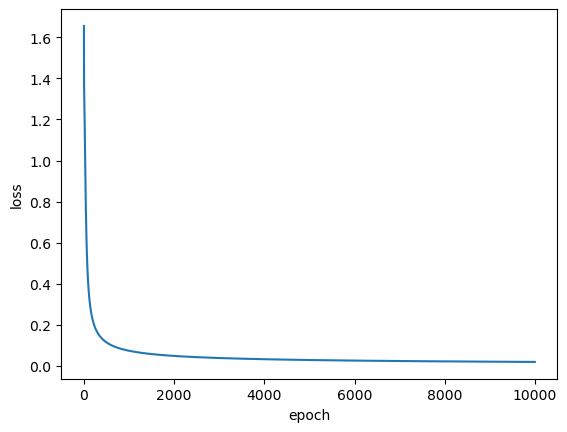

In [110]:
plt.plot(lossArray)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

### fit 이란 이름의 함수화

In [118]:
def fit(X, W1, W2, b1, b2, z, it_max=60000):
    lossArray = []
    learning_rate = 5
    for epoch in range(it_max):
        # prediction
        layer0, layer1, layer2 = prediction(X, W1, W2, b1, b2)
        z_2_hat = layer2
    
        # check break condition
        decision = z_2_hat >= 0.5
        error = np.sum(np.abs(decision-z))
        loss = np.sum(np.abs(z_2_hat-z))
        lossArray.append(loss)
        print(epoch, error, loss, z_2_hat.T)
        if error == 0: break 
        
        # Backpropagation
        layer2_error = layer2 - z
        layer2_delta = layer2_error * sigmoid_derivative(layer2)
        dW2 = np.dot(layer1.T, layer2_delta) / len(layer2_delta)
        db2 = np.sum(layer2_delta, axis=0) / len(layer2_delta)
    
        layer1_error = np.dot(layer2_delta, W2.T)
        layer1_delta = layer1_error * sigmoid_derivative(layer1)
        dW1 = np.dot(layer0.T, layer1_delta) / len(layer1_delta)
        db1 = np.sum(layer1_delta, axis=0) / len(layer1_delta)
    
        # Update
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    return W1, W2, b1, b2, np.array(lossArray), decision

In [119]:
it_max = 10000
W1_out, W2_out, b1_out, b2_out, lossArray, decision = fit(X, W1, W2, b1, b2, z, it_max)

0 3 2.929035191483891 [[0.18205918 0.10801008 0.08302358 0.06199033]]
1 3 2.7893757291910783 [[0.29616479 0.21200389 0.16037817 0.134407  ]]
2 4 2.306080720527054 [[0.52523945 0.47594763 0.37493092 0.36828017]]
3 1 1.6185052986138087 [[0.74902172 0.76080519 0.66710235 0.70260889]]
4 1 1.4995188749223456 [[0.77875119 0.80108957 0.7187236  0.75941915]]
5 1 1.4572098401919389 [[0.78445306 0.81276145 0.73559512 0.77888665]]
6 1 1.4365221975541917 [[0.78301237 0.81640868 0.742256   0.7878255 ]]
7 1 1.4249680121298738 [[0.77824077 0.8165767  0.74441388 0.79228217]]
8 1 1.4177624364503867 [[0.77161477 0.81499678 0.74429151 0.79456405]]
9 1 1.412612914178758 [[0.76385695 0.81250323 0.74296743 0.79577337]]
10 1 1.4082860698374142 [[0.75536691 0.80955102 0.74102836 0.79650146]]
11 1 1.4040786822790365 [[0.7463793  0.80640414 0.73881245 0.79708403]]
12 1 1.399580052393452 [[0.73703474 0.8032195  0.73651968 0.79771551]]
13 1 1.394549135847618 [[0.72741723 0.80009059 0.73426948 0.79850802]]
14 1 1.

In [120]:
import matplotlib.pyplot as plt

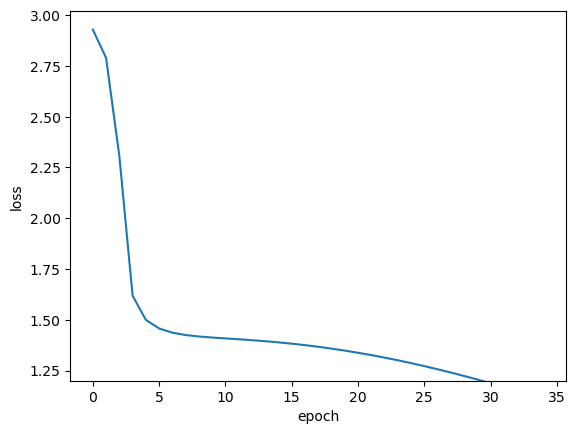

In [123]:
plt.plot(lossArray)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.ylim(1.2)
plt.show()

## 2 hidden layers

In [130]:
inputs, hiddens1, hiddens2, outputs = 2, 3, 3, 1
W1 = np.random.randn(inputs, hiddens1)
W2 = np.random.randn(hiddens1, hiddens2)
W3 = np.random.randn(hiddens2, outputs)
b1 = np.zeros(hiddens1)
b2 = np.zeros(hiddens2)
b3 = np.zeros(outputs)

In [131]:
def prediction(X, W1, W2, W3, b1, b2, b3):
    layer0 = X
    y1 = np.dot(layer0, W1) + b1
    layer1 = sigmoid(y1)
    y2 = np.dot(layer1, W2) + b2
    layer2 = sigmoid(y2)
    y3 = np.dot(layer2, W3) + b3
    layer3 = sigmoid(y3)
    return layer0, layer1, layer2, layer3

In [128]:
learning_rate = 1.5
for epoch in range(10000):
    # prediction
    layer0, layer1, layer2, layer3 = prediction(X, W1, W2, W3, b1, b2, b3)
    z_3_hat = layer3

    # check break condition
    decision = z_3_hat >= 0.5
    error = np.sum(np.abs(decision-z))
    print(epoch, error, z_3_hat.T)
    if error == 0:
        break

    # Backpropagation
    layer3_error = layer3 - z
    layer3_delta = layer3_error * sigmoid_derivative(layer3)
    dW3 = np.dot(layer2.T, layer3_delta) / len(layer3_delta)
    db3 = np.sum(layer3_delta, axis=0) / len(layer3_delta)

    layer2_error = np.dot(layer3_delta, W3.T)
    layer2_delta = layer2_error * sigmoid_derivative(layer2)
    dW2 = np.dot(layer1.T, layer2_delta) / len(layer2_delta)
    db2 = np.sum(layer2_delta, axis=0) / len(layer2_delta)

    layer1_error = np.dot(layer2_delta, W2.T)
    layer1_delta = layer1_error * sigmoid_derivative(layer1)
    dW1 = np.dot(layer0.T, layer1_delta) / len(layer1_delta)
    db1 = np.sum(layer1_delta, axis=0) / len(layer1_delta)

    # Update
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

0 3 [[0.44038394 0.4512607  0.44986752 0.45821456]]
1 2 [[0.48731537 0.49565202 0.49497776 0.50181409]]
2 1 [[0.52725595 0.53334305 0.53328137 0.53877534]]
3 1 [[0.56035592 0.56457312 0.56500627 0.56937783]]
4 1 [[0.58748949 0.59020644 0.59102785 0.59449197]]
5 1 [[0.60970825 0.61124345 0.61236518 0.61510817]]
6 1 [[0.62798    0.62859293 0.62994549 0.63212015]]
7 1 [[0.64310731 0.64300434 0.6445337  0.64626244]]
8 1 [[0.65572646 0.65507048 0.6567348  0.65811493]]
9 1 [[0.66633307 0.66525278 0.66701951 0.6681285 ]]
10 1 [[0.67531162 0.67390927 0.67575292 0.67665275]]
11 1 [[0.68296129 0.68131879 0.68321921 0.68395984]]
12 1 [[0.68951645 0.68769998 0.68964109 0.69026316]]
13 1 [[0.69516228 0.69322581 0.69519463 0.69573149]]
14 1 [[0.70004639 0.69803435 0.70002032 0.70049955]]
15 1 [[0.70428759 0.70223687 0.7042313  0.70467595]]
16 1 [[0.70798235 0.70592384 0.70791954 0.70834897]]
17 1 [[0.71120969 0.70916947 0.71116043 0.71159106]]
18 1 [[0.71403487 0.71203513 0.71401628 0.71446214]]
19 

## 2 hidden layers 함수화

In [132]:
def fit2(X, W1, W2, W3, b1, b2, b3, z, it_max=10000):
    lossArray = [] #######
    learning_rate = 1.5
    for epoch in range(10000):
        # prediction
        layer0, layer1, layer2, layer3 = prediction(X, W1, W2, W3, b1, b2, b3)
        z_3_hat = layer3
    
        # check break condition
        decision = z_3_hat >= 0.5
        error = np.sum(np.abs(decision-z))
        lossArray.append(np.sum(np.abs(z_3_hat-z))) ######
        # print(epoch, error, z_3_hat.T)
        if error == 0:
            break
    
        # Backpropagation
        layer3_error = layer3 - z
        layer3_delta = layer3_error * sigmoid_derivative(layer3)
        dW3 = np.dot(layer2.T, layer3_delta) / len(layer3_delta)
        db3 = np.sum(layer3_delta, axis=0) / len(layer3_delta)
    
        layer2_error = np.dot(layer3_delta, W3.T)
        layer2_delta = layer2_error * sigmoid_derivative(layer2)
        dW2 = np.dot(layer1.T, layer2_delta) / len(layer2_delta)
        db2 = np.sum(layer2_delta, axis=0) / len(layer2_delta)
    
        layer1_error = np.dot(layer2_delta, W2.T)
        layer1_delta = layer1_error * sigmoid_derivative(layer1)
        dW1 = np.dot(layer0.T, layer1_delta) / len(layer1_delta)
        db1 = np.sum(layer1_delta, axis=0) / len(layer1_delta)
    
        # Update
        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
    return W1, W2, W3, b1, b2, b3, np.array(lossArray)

In [133]:
it_max=10000
W1, W2, W3, b1, b2, b3, lossArray = fit2(X, W1, W2, W3, b1, b2, b3, z, it_max)

In [134]:
len(lossArray)

272

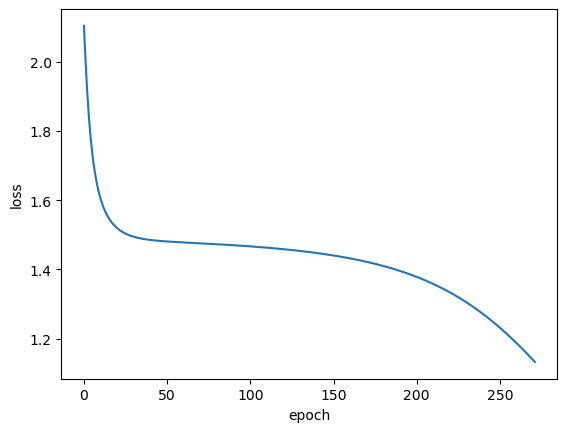

In [135]:
import matplotlib.pyplot as plt
plt.plot(lossArray)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()